In [1]:
from __future__ import annotations
import math
import random
import re
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import amp
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import timm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


In [2]:
!pwd

%cd /kaggle/input/hmdb51/HMDB51

/kaggle/working
/kaggle/input/hmdb51/HMDB51


In [3]:
class VideoTransform:
    def __init__(self, image_size: int, is_train: bool = True):
        self.image_size = image_size
        self.is_train = is_train
        self.mean = [0.5, 0.5, 0.5]
        self.std = [0.5, 0.5, 0.5]

    def __call__(self, frames: torch.Tensor) -> torch.Tensor:
        # frames: [T, C, H, W]

        if self.is_train:
            # Random resized crop (scale 0.8-1.0)
            h, w = frames.shape[-2:]
            scale = random.uniform(0.8, 1.0)
            new_h, new_w = int(h * scale), int(w * scale)
            frames = TF.resize(frames, [new_h, new_w], interpolation=InterpolationMode.BILINEAR)

            # Random crop to target size
            i = random.randint(0, max(0, new_h - self.image_size))
            j = random.randint(0, max(0, new_w - self.image_size))
            frames = TF.crop(frames, i, j, min(self.image_size, new_h), min(self.image_size, new_w))
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=InterpolationMode.BILINEAR)

            # Horizontal flip
            if random.random() < 0.5:
                frames = TF.hflip(frames)

            # Color jitter (brightness, contrast, saturation) - nhẹ
            if random.random() < 0.3:
                brightness_factor = random.uniform(0.9, 1.1)
                frames = TF.adjust_brightness(frames, brightness_factor)

            if random.random() < 0.3:
                contrast_factor = random.uniform(0.9, 1.1)
                frames = TF.adjust_contrast(frames, contrast_factor)

            if random.random() < 0.3:
                saturation_factor = random.uniform(0.9, 1.1)
                frames = TF.adjust_saturation(frames, saturation_factor)
        else:
            # Val/test: center crop
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=InterpolationMode.BILINEAR)

        # Normalize
        normalized = [TF.normalize(frame, self.mean, self.std) for frame in frames]
        return torch.stack(normalized)

In [4]:
class HMDB51Dataset(Dataset):
    """Load HMDB51 frame folders with grouped train/val split."""
    def __init__(self, root: str, split: str, num_frames: int, frame_stride: int, image_size: int = 224, transform: Optional[VideoTransform] = None, val_ratio: float = 0.1, seed: int = 42):
        super().__init__()
        self.root = Path(root)
        if not self.root.is_dir():
            raise FileNotFoundError(f"Data root not found: {self.root}")
        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        if not self.classes:
            raise RuntimeError(f"No class folders in {self.root}")
        self.class_to_idx = {name: idx for idx, name in enumerate(self.classes)}
        grouped_samples: Dict[Tuple[str, str], List[Tuple[List[Path], int]]] = {}
        for cls in self.classes:
            cls_dir = self.root / cls
            for video_dir in sorted([d for d in cls_dir.iterdir() if d.is_dir()]):
                frame_paths = sorted([p for p in video_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
                if not frame_paths:
                    continue
                group_key = (cls, self._base_video_name(video_dir.name))
                grouped_samples.setdefault(group_key, []).append((frame_paths, self.class_to_idx[cls]))
        if not grouped_samples:
            raise RuntimeError(f"No frame folders found inside {self.root}")
        group_values = list(grouped_samples.values())
        rng = np.random.RandomState(seed)
        group_indices = np.arange(len(group_values))
        rng.shuffle(group_indices)
        split_point = int(len(group_indices) * (1 - val_ratio))
        if split == "train":
            selected_groups = group_indices[:split_point]
        elif split in ("val", "test"):
            selected_groups = group_indices[split_point:]
        else:
            raise ValueError(f"Unknown split: {split}")
        samples: List[Tuple[List[Path], int]] = []
        for idx in selected_groups:
            samples.extend(group_values[int(idx)])
        if not samples:
            raise RuntimeError("Selected split has no samples; adjust val_ratio or data folders.")
        self.samples = samples
        self.split = split
        self.num_frames = num_frames
        self.frame_stride = max(1, frame_stride)
        self.transform = transform or VideoTransform(image_size, is_train=(split == "train"))
        self.to_tensor = transforms.ToTensor()
    def __len__(self) -> int:
        return len(self.samples)
    def _select_indices(self, total: int) -> torch.Tensor:
        if total <= 0:
            raise ValueError("Video folder has no frames")
        if total == 1:
            return torch.zeros(self.num_frames, dtype=torch.long)
        steps = max(self.num_frames * self.frame_stride, self.num_frames)
        grid = torch.linspace(0, total - 1, steps=steps)
        idxs = grid[:: self.frame_stride].long()
        if idxs.numel() < self.num_frames:
            pad = idxs.new_full((self.num_frames - idxs.numel(),), idxs[-1].item())
            idxs = torch.cat([idxs, pad], dim=0)
        return idxs[: self.num_frames]
        
    @staticmethod
    def _base_video_name(name: str) -> str:
        match = re.match(r"(.+)_\d+$", name)
        return match.group(1) if match else name
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        frame_paths, label = self.samples[idx]
        total = len(frame_paths)
        idxs = self._select_indices(total)
        frames = []
        for i in idxs:
            path = frame_paths[int(i.item())]
            with Image.open(path) as img:
                img = img.convert("RGB")
                frames.append(self.to_tensor(img))
        video = torch.stack(frames)
        video = self.transform(video)
        return video, label


def collate_fn(batch: List[Tuple[torch.Tensor, int]]) -> Tuple[torch.Tensor, torch.Tensor]:
    videos = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return videos, labels

In [5]:
DATA_ROOT = '/kaggle/input/hmdb51/HMDB51'
VAL_RATIO = 0.1
SEED = 42
NUM_FRAMES = 16
FRAME_STRIDE = 2
IMG_SIZE = 224
BATCH_SIZE = 4

train_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split='train',
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)
val_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split='val',
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    collate_fn=collate_fn,
)

MEAN = [0.5, 0.5, 0.5]
STD = [0.5, 0.5, 0.5]

def denormalize(frames):
    frames = frames.clone()
    for c in range(frames.shape[1]):
        frames[:, c] = frames[:, c] * STD[c] + MEAN[c]
    return frames.clamp(0, 1)

print(f'Train clips: {len(train_dataset)} | Val clips: {len(val_dataset)}')
print(f'Class count: {len(train_dataset.classes)}')

Train clips: 6121 | Val clips: 645
Class count: 51


---
# Check Imbalance on train and val

In [6]:
print(train_dataset.__dict__.keys())

dict_keys(['root', 'classes', 'class_to_idx', 'samples', 'split', 'num_frames', 'frame_stride', 'transform', 'to_tensor'])


In [7]:
def fast_count(dataset):
    counts = {}
    for _, label in dataset.samples:
        counts[label] = counts.get(label, 0) + 1
    return counts

def reorder_counts(counts, classes):
    # classes = ['brush_hair', 'cartwheel', ...]
    return {
        cls: counts.get(i, 0)
        for i, cls in enumerate(classes)
    }

train_counts = fast_count(train_dataset)
val_counts   = fast_count(val_dataset)

train_counts_named = reorder_counts(train_counts, train_dataset.classes)
val_counts_named   = reorder_counts(val_counts, val_dataset.classes)



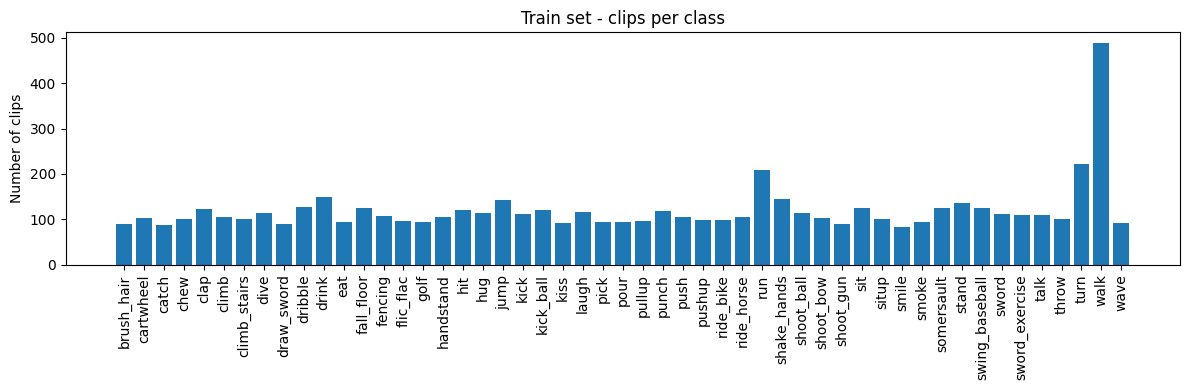

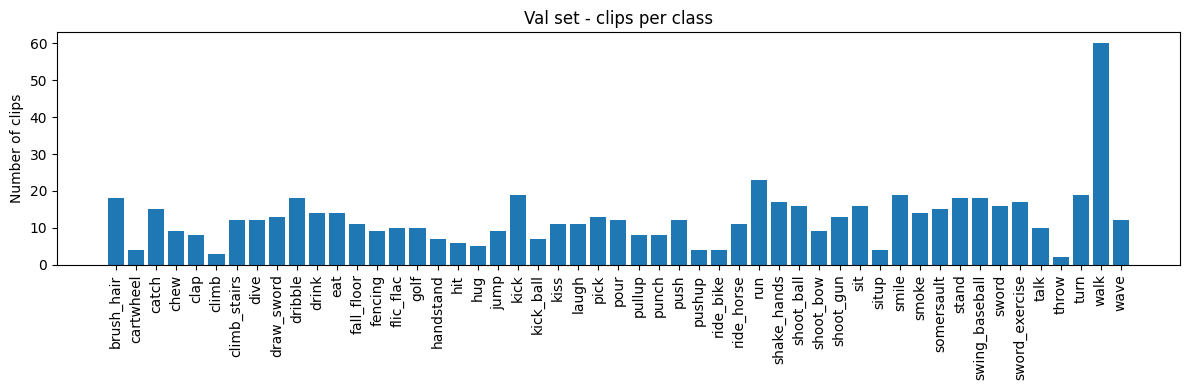

In [8]:
def plot_counts(counts, title):
    plt.figure(figsize=(12,4))
    plt.bar(counts.keys(), counts.values())
    plt.xticks(rotation=90)
    plt.title(title)
    plt.ylabel("Number of clips")
    plt.tight_layout()
    plt.show()

plot_counts(train_counts_named, "Train set - clips per class")
plot_counts(val_counts_named, "Val set - clips per class")

---

# Check size

In [9]:
print(type(train_dataset.samples[0]))
print(train_dataset.samples[0])

<class 'tuple'>
([PosixPath('/kaggle/input/hmdb51/HMDB51/catch/Torwarttraining_catch_f_cm_np1_ba_bad_10/10000.jpg'), PosixPath('/kaggle/input/hmdb51/HMDB51/catch/Torwarttraining_catch_f_cm_np1_ba_bad_10/10001.jpg'), PosixPath('/kaggle/input/hmdb51/HMDB51/catch/Torwarttraining_catch_f_cm_np1_ba_bad_10/10002.jpg'), PosixPath('/kaggle/input/hmdb51/HMDB51/catch/Torwarttraining_catch_f_cm_np1_ba_bad_10/10003.jpg'), PosixPath('/kaggle/input/hmdb51/HMDB51/catch/Torwarttraining_catch_f_cm_np1_ba_bad_10/10004.jpg'), PosixPath('/kaggle/input/hmdb51/HMDB51/catch/Torwarttraining_catch_f_cm_np1_ba_bad_10/10005.jpg'), PosixPath('/kaggle/input/hmdb51/HMDB51/catch/Torwarttraining_catch_f_cm_np1_ba_bad_10/10006.jpg')], 2)


In [10]:
#Size raw images

def check_sizes_from_samples(dataset, name):
    sizes = []
    for path, label in dataset.samples:
        img = Image.open(path[0])
        sizes.append(img.size)

    sizes = np.array(sizes)
    print(f"{name}")
    print("Width  min / max / mean:", sizes[:,0].min(), sizes[:,0].max(), sizes[:,0].mean())
    print("Height min / max / mean:", sizes[:,1].min(), sizes[:,1].max(), sizes[:,1].mean())
    print("-"*50)

check_sizes_from_samples(train_dataset, "TRAIN")
check_sizes_from_samples(val_dataset,   "VAL")


TRAIN
Width  min / max / mean: 176 592 365.8317268420193
Height min / max / mean: 240 240 240.0
--------------------------------------------------
VAL
Width  min / max / mean: 288 592 376.07441860465116
Height min / max / mean: 240 240 240.0
--------------------------------------------------


In [11]:
#Transformed in HMDB51Dataset function 

def check_sizes(dataset, name, n_sample=200):
    sizes = []
    for i in range(min(len(dataset), n_sample)):
        frames, label = dataset[i]   # frames: (T, C, H, W)
        _, _, H, W = frames.shape
        sizes.append((W, H))

    sizes = np.array(sizes)
    print(f"{name}")
    print("Width  min / max / mean:", sizes[:,0].min(), sizes[:,0].max(), sizes[:,0].mean())
    print("Height min / max / mean:", sizes[:,1].min(), sizes[:,1].max(), sizes[:,1].mean())
    print("-"*50)

check_sizes(train_dataset, "TRAIN")
check_sizes(val_dataset,   "VAL")


TRAIN
Width  min / max / mean: 224 224 224.0
Height min / max / mean: 224 224 224.0
--------------------------------------------------
VAL
Width  min / max / mean: 224 224 224.0
Height min / max / mean: 224 224 224.0
--------------------------------------------------


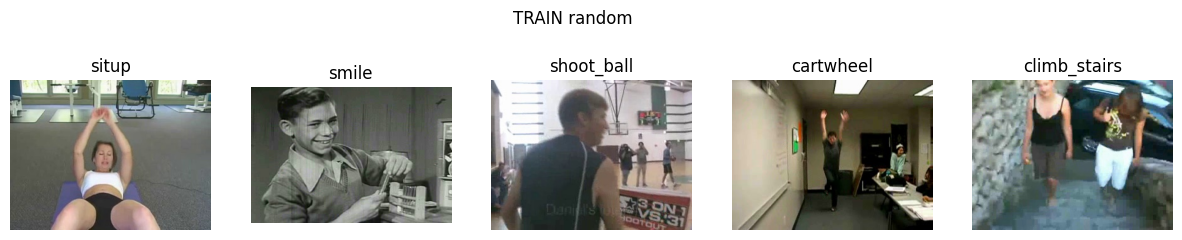

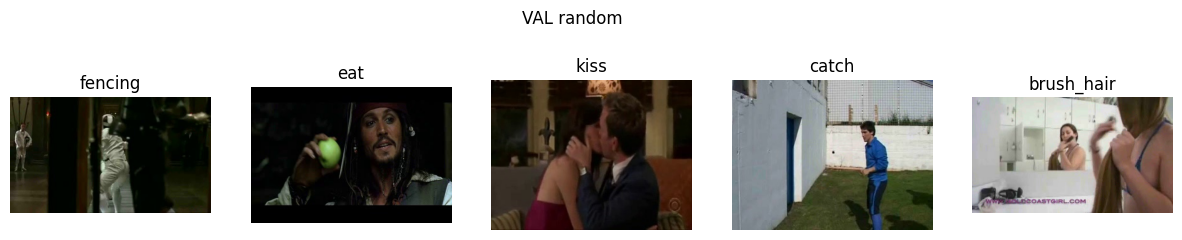

In [12]:
#5 random samples in Train and Val
def show_random_samples(dataset, n_sample=5, title=""):
    idxs = random.sample(range(len(dataset.samples)), n_sample)

    plt.figure(figsize=(15, 3))

    for i, idx in enumerate(idxs):
        frame_paths, label = dataset.samples[idx]

        img_path = frame_paths[0]          # frame đầu
        img = Image.open(img_path).convert("RGB")

        plt.subplot(1, n_sample, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(dataset.classes[label])

    plt.suptitle(title)
    plt.show()

show_random_samples(train_dataset, 5, "TRAIN random")
show_random_samples(val_dataset,   5, "VAL random")


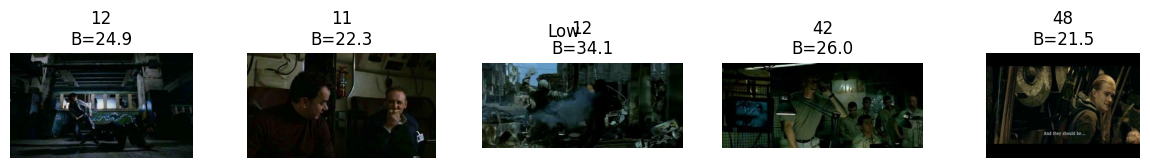

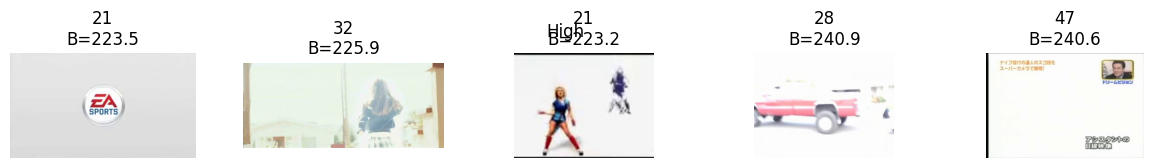

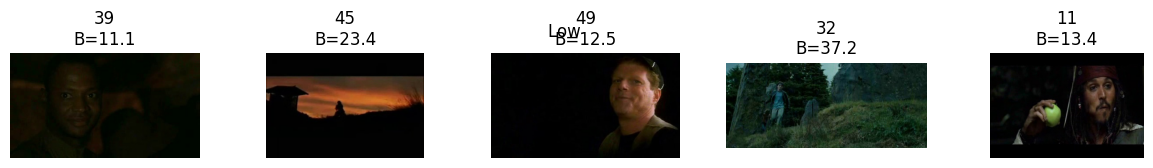

<Figure size 1500x300 with 0 Axes>

In [13]:
#Dark and Bright pictures  
def image_brightness(img):
    gray = img.convert("L")          # grayscale
    return np.array(gray).mean()     # 0 → 255

def collect_abnormal_frames(
    dataset,
    n_sample=5,
    low_thr=40,
    high_thr=220
):
    low_imgs  = []
    high_imgs = []

    for frame_paths, label in dataset.samples:
        img_path = random.choice(frame_paths)   # random frame
        img = Image.open(img_path).convert("RGB")
        b = image_brightness(img)

        if b < low_thr and len(low_imgs) < n_sample:
            low_imgs.append((img, label, b))
        elif b > high_thr and len(high_imgs) < n_sample:
            high_imgs.append((img, label, b))

        if len(low_imgs) == n_sample and len(high_imgs) == n_sample:
            break

    return low_imgs, high_imgs

def show_abnormal(imgs, title):
    plt.figure(figsize=(15, 3))
    for i, (img, label, b) in enumerate(imgs):
        plt.subplot(2, len(imgs), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{label}\nB={b:.1f}")
    plt.suptitle(title)
    plt.show()

low_imgs_train, high_imgs_train = collect_abnormal_frames(train_dataset)
low_imgs_val, high_imgs_val = collect_abnormal_frames(val_dataset)

show_abnormal(low_imgs_train,  "Low")
show_abnormal(high_imgs_train, "High")

show_abnormal(low_imgs_val,  "Low ")
show_abnormal(high_imgs_val, "High")

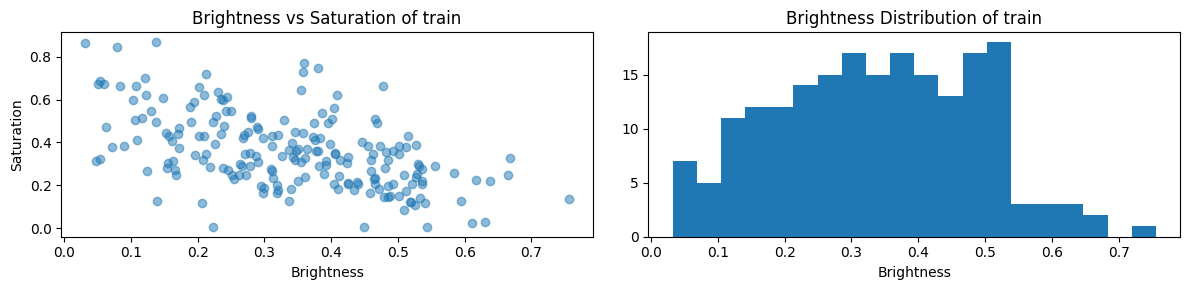

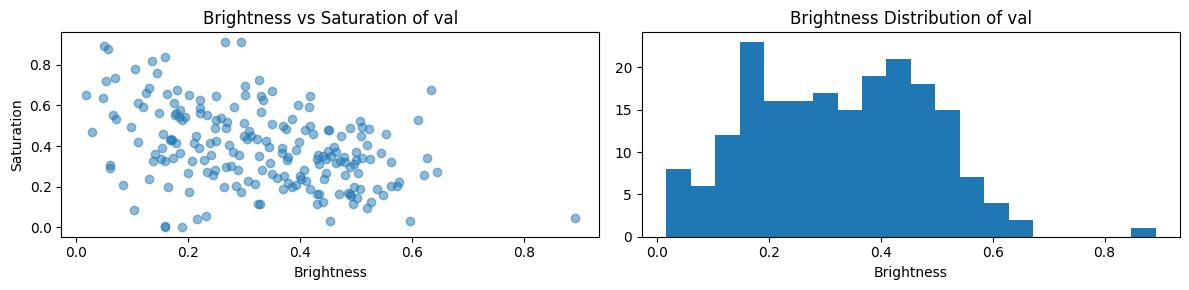

In [14]:
from colorsys import rgb_to_hsv

def brightness_saturation_scatter(dataset, tittle, max_samples=200):
    br_list, sat_list = [], []

    samples = random.sample(dataset.samples, min(max_samples, len(dataset.samples)))

    for frame_paths, _ in samples:
        path = random.choice(frame_paths)
        img = Image.open(path).convert("RGB")
        arr = np.array(img) / 255.0  # normalize 0-1
        r,g,b = arr[:,:,0], arr[:,:,1], arr[:,:,2]

        # tính brightness = mean grayscale
        brightness = 0.299*r + 0.587*g + 0.114*b
        br_list.append(np.mean(brightness))

        # tính saturation trung bình
        hsv = np.vectorize(rgb_to_hsv)(r, g, b)
        sat = hsv[1]  # channel S
        sat_list.append(np.mean(sat))

    plt.figure(figsize=(12,3))   
    
    plt.subplot(1, 2, 1)         
    plt.scatter(br_list, sat_list, alpha=0.5)
    plt.xlabel("Brightness")
    plt.ylabel("Saturation")
    plt.title(f"Brightness vs Saturation of {tittle}")
    
    plt.subplot(1, 2, 2)       
    plt.hist(br_list, bins=20)
    plt.xlabel("Brightness")
    plt.title(f"Brightness Distribution of {tittle}")
    
    plt.tight_layout()
    plt.show()
# Sử dụng
brightness_saturation_scatter(train_dataset, "train")
brightness_saturation_scatter(val_dataset, "val")

In [15]:
def count_bad_images(dataset):
    bad_count = 0
    for frame_paths, label in dataset.samples:
        for path in frame_paths:
            try:
                img = Image.open(path)
                img.verify()  # kiểm tra file corrupt
            except Exception as e:
                bad_count += 1
                # print(path, e)   # nếu muốn xem path lỗi
    return bad_count

# Test
bad_train = count_bad_images(train_dataset)
bad_val   = count_bad_images(val_dataset)

print(f"Train dataset: {bad_train} bad images")
print(f"Val dataset:   {bad_val} bad images")

Train dataset: 0 bad images
Val dataset:   0 bad images


KeyboardInterrupt: 

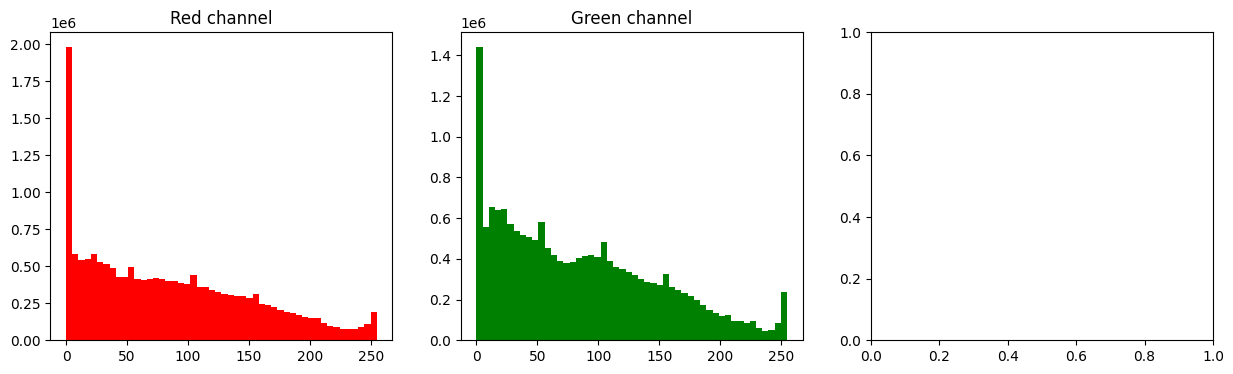

In [16]:
def color_histogram(dataset, max_samples=200):
    r_list, g_list, b_list = [], [], []

    samples = random.sample(dataset.samples, min(max_samples, len(dataset.samples)))
    for frame_paths, _ in samples:
        path = random.choice(frame_paths)
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        r_list.extend(arr[:,:,0].flatten())
        g_list.extend(arr[:,:,1].flatten())
        b_list.extend(arr[:,:,2].flatten())

    fig, axes = plt.subplots(1,3, figsize=(15,4))
    axes[0].hist(r_list, bins=50, color='r')
    axes[0].set_title("Red channel")
    axes[1].hist(g_list, bins=50, color='g')
    axes[1].set_title("Green channel")
    axes[2].hist(b_list, bins=50, color='b')
    axes[2].set_title("Blue channel")
    plt.show()

# Sử dụng
color_histogram(train_dataset)
color_histogram(val_dataset)

In [20]:
import timm

class ActionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # CNN backbone (VERY strong)
        self.backbone = timm.create_model('resnet18', pretrained=True)
        self.backbone.fc = nn.Identity()  # remove classifier
        
        self.lstm = nn.LSTM(512, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        
        x = x.view(B*T, C, H, W)
        features = self.backbone(x)  # (B*T, 512)
        
        features = features.view(B, T, -1)
        
        out, _ = self.lstm(features)
        out = out[:, -1]  # last frame
        
        return self.fc(out)

In [ ]:
model = ActionModel(num_classes=len(train_dataset.classes)).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    total_loss = 0
    
    for videos, labels in tqdm(train_loader):
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

  0%|          | 0/1531 [00:00<?, ?it/s]